# 03PCA_Feature_Fusion 노트북 목표
1. KcBERT 임베딩을 PCA로 차원 축소한다.
2. 차원 축소된 텍스트 feature와 메타데이터를 결합해 feature fusion 구조를 확인한다.
3. 04번 이후 학습 노트북에서 사용할 전처리 흐름을 미리 검토한다.

- KcBERT 임베딩은 768차원이라 그대로 사용하면 계산량이 크고 과적합 위험이 있다.
- PCA는 임베딩의 주요 분산 정보를 보존하면서 차원을 줄이는 데 사용한다.
- `text_length`, `emoji_count`, `photo_count`는 텍스트 외 행동 메타데이터로 함께 확인한다.
- 이 노트북은 구조 확인용이며, 실제 모델 학습은 04번의 pipeline 안에서 다시 수행한다.


## 1. 라이브러리 로드
- 임베딩 차원 축소, 메타데이터 정규화, train/validation/test 분할을 위한 패키지를 불러온다.
- 각 패키지의 역할은 다음과 같다.
    1. `pandas`: CSV 데이터를 불러오고 결과 데이터프레임을 만든다.
    2. `numpy`: 임베딩과 메타데이터 배열을 결합한다.
    3. `matplotlib`: PCA 누적 설명 분산 비율을 시각화한다.
    4. `PCA`: KcBERT 임베딩 차원을 줄인다.
    5. `StandardScaler`: 메타데이터 스케일을 표준화한다.
    6. `train_test_split`: 데이터를 train/validation/test로 나눈다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 2. 데이터 로드 및 입력 분리
- 02번에서 생성한 `reviews_embeddings_extract.csv`를 불러온다.
- `kcbert_0`부터 `kcbert_767`까지를 KcBERT 임베딩 feature로 사용한다.
- 메타데이터 feature는 `text_length`, `emoji_count`, `photo_count`만 사용한다.
- label은 모델이 맞춰야 하는 정답값이므로 입력 feature와 분리한다.
- 데이터는 train 70%, validation 15%, test 15%로 나눈다.  


In [2]:
df = pd.read_csv('csv/reviews_embeddings_extract.csv')

# KcBERT 임베딩 컬럼
emb_cols = [f'kcbert_{i}' for i in range(768)]

# 이벤트 판별용 메타데이터 컬럼
meta_cols = ['text_length', 'emoji_count', 'photo_count']

# 입력 데이터와 라벨 분리
X_emb = df[emb_cols].values
X_meta = df[meta_cols].values
y = df['label'].values

# 1차 분할: train 70%, temp 30%
X_emb_train, X_emb_temp, X_meta_train, X_meta_temp, y_train, y_temp = train_test_split(
    X_emb,
    X_meta,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: validation 15%, test 15%
X_emb_val, X_emb_test, X_meta_val, X_meta_test, y_val, y_test = train_test_split(
    X_emb_temp,
    X_meta_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"전체 임베딩 형태: {X_emb.shape}")
print(f"학습 임베딩 형태: {X_emb_train.shape}")
print(f"검증 임베딩 형태: {X_emb_val.shape}")
print(f"테스트 임베딩 형태: {X_emb_test.shape}")
print(f"사용 메타데이터 컬럼: {meta_cols}")

전체 임베딩 형태: (8841, 768)
학습 임베딩 형태: (6188, 768)
검증 임베딩 형태: (1326, 768)
테스트 임베딩 형태: (1327, 768)
사용 메타데이터 컬럼: ['text_length', 'emoji_count', 'photo_count']


/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_75368/776719719.py:1: DtypeWarning: Columns (0: store_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('csv/reviews_embeddings_extract.csv')


## 3. PCA 차원 축소 및 시각화
- KcBERT 768차원 임베딩을 PCA로 축소한다.
- 현재는 학습 데이터 기준으로 분산 정보의 90%를 보존하도록 설정한다.
- validation/test 데이터에는 train에서 학습한 PCA 변환만 적용한다.
- 누적 설명 분산 비율 그래프로 몇 개의 주성분이 필요한지 확인한다.

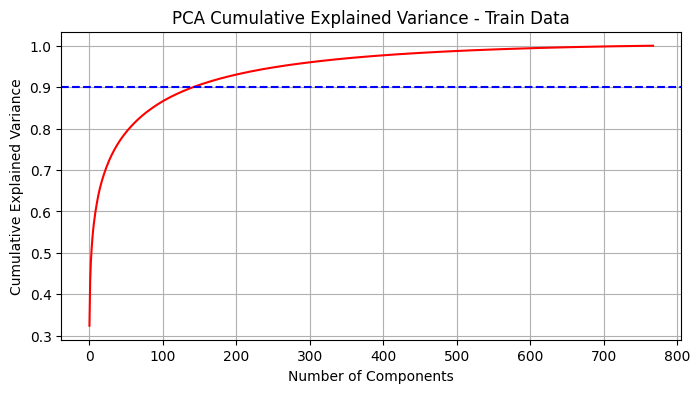

차원 축소 전 학습 데이터 형태: (6188, 768)
차원 축소 후 학습 데이터 형태: (6188, 143)
차원 축소 후 검증 데이터 형태: (1326, 143)
차원 축소 후 테스트 데이터 형태: (1327, 143)
PCA 선택 차원 수: 143


In [3]:
# 학습 데이터 기준으로만 PCA fit
pca = PCA(n_components=0.90, random_state=42)

X_emb_train_pca = pca.fit_transform(X_emb_train)
X_emb_val_pca = pca.transform(X_emb_val)
X_emb_test_pca = pca.transform(X_emb_test)

# 시각화도 학습 데이터 기준으로만 확인
pca_full = PCA().fit(X_emb_train)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red')
plt.axhline(y=0.9, color='blue', linestyle='--')
plt.title('PCA Cumulative Explained Variance - Train Data')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

print(f"차원 축소 전 학습 데이터 형태: {X_emb_train.shape}")
print(f"차원 축소 후 학습 데이터 형태: {X_emb_train_pca.shape}")
print(f"차원 축소 후 검증 데이터 형태: {X_emb_val_pca.shape}")
print(f"차원 축소 후 테스트 데이터 형태: {X_emb_test_pca.shape}")
print(f"PCA 선택 차원 수: {pca.n_components_}")

## 4. 메타데이터 정규화
- `text_length`, `emoji_count`, `photo_count`는 값의 단위와 범위가 서로 다르다.
- `StandardScaler`를 사용해 평균 0, 표준편차 1 기준으로 맞춘다.
- scaler는 train 데이터에만 fit하고, validation/test에는 transform만 적용한다.
- 이렇게 해야 validation/test 분포 정보가 학습 단계에 섞이는 데이터 누수를 줄일 수 있다.


In [4]:
# 학습 데이터 기준으로만 StandardScaler fit
scaler = StandardScaler()

X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_val_scaled = scaler.transform(X_meta_val)
X_meta_test_scaled = scaler.transform(X_meta_test)

print(f"스케일링 전 학습 메타데이터 예시:\n{X_meta_train[0]}")
print(f"스케일링 후 학습 메타데이터 예시:\n{X_meta_train_scaled[0]}")
print(f"학습 메타데이터 형태: {X_meta_train_scaled.shape}")
print(f"검증 메타데이터 형태: {X_meta_val_scaled.shape}")
print(f"테스트 메타데이터 형태: {X_meta_test_scaled.shape}")

스케일링 전 학습 메타데이터 예시:
[52  0  1]
스케일링 후 학습 메타데이터 예시:
[-0.08208463 -0.15769423  0.12837092]
학습 메타데이터 형태: (6188, 3)
검증 메타데이터 형태: (1326, 3)
테스트 메타데이터 형태: (1327, 3)


## 5. Feature Fusion 구조 확인
- PCA로 축소한 KcBERT 임베딩과 정규화한 메타데이터를 하나의 입력 벡터로 결합한다.
- 결합된 feature 컬럼은 `feat_0`, `feat_1` 형식으로 만든다.
- 마지막 메타데이터 컬럼은 해석하기 쉽도록 다시 이름을 지정한다.
- 정답 label은 `target_label` 컬럼으로 추가해 구조 확인에 사용한다.
- 03번에서 만든 결합 데이터는 후속 학습 입력으로 저장하지 않는다.


In [5]:
# PCA 임베딩과 정규화된 메타데이터 결합
X_train_final = np.hstack([X_emb_train_pca, X_meta_train_scaled])
X_val_final = np.hstack([X_emb_val_pca, X_meta_val_scaled])
X_test_final = np.hstack([X_emb_test_pca, X_meta_test_scaled])

# PCA 차원 수 확인
pca_dim = X_emb_train_pca.shape[1]

# 컬럼명 생성
column_names = [f'feat_{i}' for i in range(X_train_final.shape[1])]

df_train_final = pd.DataFrame(X_train_final, columns=column_names)
df_val_final = pd.DataFrame(X_val_final, columns=column_names)
df_test_final = pd.DataFrame(X_test_final, columns=column_names)

# 정답 label 추가
df_train_final['target_label'] = y_train
df_val_final['target_label'] = y_val
df_test_final['target_label'] = y_test

# 마지막 3개 컬럼명을 메타데이터 이름으로 변경
rename_dict = {
    f'feat_{pca_dim}': 'meta_text_length',
    f'feat_{pca_dim + 1}': 'meta_emoji_count',
    f'feat_{pca_dim + 2}': 'meta_photo_count'
}

df_train_final = df_train_final.rename(columns=rename_dict)
df_val_final = df_val_final.rename(columns=rename_dict)
df_test_final = df_test_final.rename(columns=rename_dict)

print(f"PCA 차원 수: {pca_dim}")
print(f"메타데이터 차원 수: {len(meta_cols)}")
print(f"최종 학습 데이터프레임 형태: {df_train_final.shape}")
print(f"최종 검증 데이터프레임 형태: {df_val_final.shape}")
print(f"최종 테스트 데이터프레임 형태: {df_test_final.shape}")

df_train_final.head()

PCA 차원 수: 143
메타데이터 차원 수: 3
최종 학습 데이터프레임 형태: (6188, 147)
최종 검증 데이터프레임 형태: (1326, 147)
최종 테스트 데이터프레임 형태: (1327, 147)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_137,feat_138,feat_139,feat_140,feat_141,feat_142,meta_text_length,meta_emoji_count,meta_photo_count,target_label
0,10.651445,-7.012392,2.687123,-0.529867,-0.301116,-1.294866,-0.092358,-0.591760,-1.351573,1.139234,...,0.069359,0.238330,0.056750,0.357368,-0.075056,-0.600130,-0.082085,-0.157694,0.128371,0
1,-1.469155,1.171581,-0.811788,-3.022353,-2.812100,-0.040615,-0.995099,0.470921,-0.825371,-0.247052,...,-0.644768,-0.145822,-0.404173,0.032653,0.347962,-0.075022,-0.403728,1.260981,-1.175996,0
2,-6.240142,-1.859455,-6.447093,-0.870571,1.621050,-3.420480,-1.412648,-1.875504,-1.406869,-3.181204,...,0.872270,-0.539741,0.194677,-0.124089,-0.679631,0.695142,-0.403728,-0.157694,0.128371,1
3,-15.023122,1.020801,6.497658,5.925089,-1.193814,2.092549,4.450788,-0.946488,1.149096,-3.115664,...,-0.055242,0.542410,0.634675,0.160666,-0.077124,-0.269376,-0.757536,-0.157694,-1.175996,0
4,3.807695,-0.339363,-0.118007,-3.310115,-1.996416,-3.045877,0.506313,1.118434,2.087951,-0.211992,...,0.281676,-0.548350,-0.116263,0.705309,0.507140,-0.042154,-0.307235,-0.157694,2.737104,0


## 6. 최종 산출물 확인
- 03번은 PCA와 feature fusion 구조를 확인하는 노트북이다.
- `final_hybrid_train.csv`, `final_hybrid_val.csv`, `final_hybrid_test.csv`는 생성하지 않는다.
- 실제 학습에서는 04번 pipeline 안에서 PCA, StandardScaler, SMOTE가 fold마다 적용된다.
- 여러 MLP 설정을 5-fold CV로 비교한 뒤, 선택된 최종 모델은 `.joblib` bundle로 저장된다.
- 따라서 최종 재사용 산출물은 03번 CSV가 아니라 04번 이후의 모델 bundle과 평가 결과 파일이다.
